In [2]:
import numpy as np
import pymc as pm
import arviz as az
# -- use this line at the beginning of your notebook to turn on interactive plots
%matplotlib notebook
import scipy.io
# note these imports, thay may be useful in your own task

import matplotlib.pyplot as plt  # plotting library
import numpy as np  # work with numeric arrays without labeled axes
import xarray as xr  # work with arrays with labeled axes
import pandas as pd

In [7]:
file_path = 'LH_metal_DB_v1.12.csv'  # 替换为你的文件路径
df = pd.read_csv(file_path)
df.loc[:, 'TOK'] = df['TOK'].str.strip()
df['IP']=df['IP'].abs()/1000000
df['BT']=df['BT'].abs()
df['PLTH']=df['PLTH']/1000000
df['NEL']=df['NEL']/1e19


df.loc[:, 'TOK'] = df['TOK'].str.strip()

reference_dict = {
    1.00:  "Hydrogen",
    2.00:  "Deuterium",
    2.50:  "Deuterium and tritium",
    3.00:  "3He or tritium",
    4.00:  "4He",
    14.01: "Nitrogen"
}

# 定义一个函数，用来根据某一观测值PGASA，返回对应的分类名称
def categorize_pgasa(value, ref_dict, tolerance=0.2):
    """
    value: 待分类的数值
    ref_dict: {参考值: 分类名称}
    tolerance: 容忍度，即 |value - 参考值| 需小于等于该值才视为同一类
    """
    # 1) 找到离 value 最近的参考值
    closest_ref = min(ref_dict.keys(), key=lambda x: abs(x - value))
    # 2) 判断两者差值是否在容忍度以内
    if abs(closest_ref - value) <= tolerance:
        return ref_dict[closest_ref]
    else:
        return np.nan  # 或者 "Other"

# 将 categorize_pgasa 应用于 df["PGASA"] 列，生成新的分类列
df["Category"] = df["PGASA"].apply(lambda x: categorize_pgasa(x, reference_dict, tolerance=0.1))

# 如果需要查看分类结果
print(df)



# 假设 subset1 是你的数据框
colors = df['SELEC2024'].map({1: 'red', 0: 'blue'})
x = df['NEL']
y = df['PLTH']
bt = df['BT'].abs()
ip= df['IP']

# 分类 BT 值
#subset2_2 = df[(ip < 2.6) & (ip >=2.4)&(bt < 3.2) & (bt >=2.8)& (df['Category'] == 'Deuterium')& (df['DIVCON'] == 'VT')]
#df = df.drop(subset2_2.index)
print(df)
import statsmodels.api as sm

# 指定你想在新 DataFrame 中包含的列
columns_to_include = ['TOK', 'SPLASMA','BT','IP','RGEO','PLTH','NEL','PGASA',"DIVCON"]
new_df = df[df['SELEC2024'] == 1][columns_to_include].copy()
mu0 = 4 * np.pi * 1e-7

new_df['BP']=1000000*(mu0 * new_df['IP']) / (new_df['SPLASMA']/(2 * np.pi * new_df['RGEO']))

new_df['PLTH/S/2']=new_df['PLTH']/(new_df['SPLASMA']*2)
new_df['a1']=new_df['SPLASMA']/(np.pi*new_df['RGEO']*2)
#new_df['PLTH/S/2']=new_df['PLTH']
# 显示新 DataFrame
print("New DataFrame:")
print(new_df)


columns_to_include_for_regre = ['BP','BT','a1','PLTH/S/2','NEL','PGASA']
unique_divcon = new_df['DIVCON'].unique()

# 2. 向原始 DataFrame 添加新列
for divcon_type in unique_divcon:
    new_df[divcon_type] = (new_df['DIVCON'] == divcon_type).astype(int)
multi_df = new_df[columns_to_include_for_regre].copy()
multi_df = multi_df.apply(np.log)
x = multi_df[['BT','BP','NEL','PGASA']] 
#x = multi_df[['BT','NEL','PGASA']]
x[unique_divcon] = new_df[unique_divcon]
#x['Xp'] = x[['Xptref','Xpthigh','Xptin']].max(axis=1)
#x.drop(['STANDARD'], axis=1, inplace=True)
x.drop(['Xptref','Xpthigh','Xptin'], axis=1, inplace=True)
x['CV'] = x[['CORNER','VT']].max(axis=1)
x.drop(['V5E','V5C','HT3R','STANDARD','V5','CORNER','VT',' VERTPLT'], axis=1, inplace=True)
X_with_intercept = sm.add_constant(x)
y=multi_df["PLTH/S/2"]
model = sm.OLS(y, X_with_intercept)
results = model.fit()

# 打印详细统计结果
print(results.summary())

# 输出系数和标准误差
coefficients = results.params
std_errors = results.bse

labels = X_with_intercept.columns  # 获取变量名
for label, coef, std_err in zip(labels, coefficients, std_errors):
    print(f"{label}: {coef:.3f} ± {std_err:.3f}")
    # 打印 RMSE
y_pred = results.predict(X_with_intercept)  # 预测值
rmse = np.sqrt(np.mean((y - y_pred) ** 2))  # 计算 RMSE

print(f"RMSE: {rmse:.3f}")
# 获取 90% 置信区间
conf_int_90 = results.conf_int(alpha=0.1)


print("\n90% 置信区间：\n", conf_int_90)
new_df[columns_to_include_for_regre]

      TOK        SHOT      TIME PHASE  PGASA      RGEO      AMIN    KAPPA  \
0    CMOD  1050428004   0.63461    LH  2.000  0.672389  0.216421  1.69737   
1    CMOD  1050428007   0.66603    LH  2.000  0.670773  0.217660  1.67073   
2    CMOD  1050621015   0.91039    LH  2.000  0.672785  0.217388  1.67962   
3    CMOD  1050621029   0.85420    LH  2.000  0.670869  0.217080  1.69789   
4    CMOD  1050623008   0.80070    LH  2.000  0.678764  0.213690  1.44202   
..    ...         ...       ...   ...    ...       ...       ...      ...   
685   JET       90527  50.99500    LH  1.962  2.900090  0.933780  1.66731   
686   JET       90528  55.16500    LH  1.916  2.901440  0.933319  1.66831   
687   JET       90737  54.56500    LH  1.940  2.901330  0.934255  1.66599   
688   JET       90738  54.46500    LH  1.961  2.898400  0.937640  1.65848   
689   JET       90742  52.16500    LH  1.983  2.900930  0.933565  1.66813   

       SPLASMA CONFIG  ...       PL     PLTH    PFLOSS PRADCORE    DIVCON  

/var/folders/5g/7cwc8n193kz9d4h5lc3ky_0c0000gn/T/ipykernel_6883/633574644.py:82: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  x[unique_divcon] = new_df[unique_divcon]


,BP,BT,a1,PLTH/S/2,NEL,PGASA
0,0.666565,5.33923,1.756693,0.154247,19.70,2.000
2,0.456655,5.32586,1.745340,0.096567,18.90,2.000
3,0.734135,5.33346,1.764206,0.092297,16.20,2.000
4,0.544822,5.26510,1.572240,0.133559,22.00,2.000
5,0.527374,5.26576,1.572899,0.135012,21.50,2.000
...,...,...,...,...,...,...
679,0.406652,2.94982,7.621669,0.028359,3.65,1.922
680,0.522389,2.93182,7.589101,0.026442,3.28,1.925
683,0.358496,2.95200,7.599663,0.026716,3.22,1.915
684,0.464494,2.94335,7.592458,0.032786,3.26,1.904


In [19]:
np.exp(X_with_intercept)

,const,BT,BP,NEL,PGASA,V5L,CV
0,2.718282,5.33923,0.666565,19.70,2.000,1.0,1.000000
2,2.718282,5.32586,0.456655,18.90,2.000,1.0,1.000000
3,2.718282,5.33346,0.734135,16.20,2.000,1.0,1.000000
4,2.718282,5.26510,0.544822,22.00,2.000,1.0,1.000000
5,2.718282,5.26576,0.527374,21.50,2.000,1.0,1.000000
...,...,...,...,...,...,...,...
679,2.718282,2.94982,0.406652,3.65,1.922,1.0,2.718282
680,2.718282,2.93182,0.522389,3.28,1.925,1.0,2.718282
683,2.718282,2.95200,0.358496,3.22,1.915,1.0,2.718282
684,2.718282,2.94335,0.464494,3.26,1.904,1.0,2.718282


Multiprocess sampling (4 chains in 4 jobs)
CompoundStep
>NUTS: [alpha, p, eta, beta_ori, beta_m, pi, sigma2]
>CategoricalGibbsMetropolis: [S]
>BinaryGibbsMetropolis: [gamma_prev, gamma]


Output()

Sampling 4 chains for 500 tune and 3_000 draw iterations (2_000 + 12_000 draws total) took 318 seconds.
There were 1677 divergences after tuning. Increase `target_accept` or reparameterize.
Chain 3 reached the maximum tree depth. Increase `max_treedepth`, increase `target_accept` or reparameterize.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


<IPython.core.display.Javascript object>


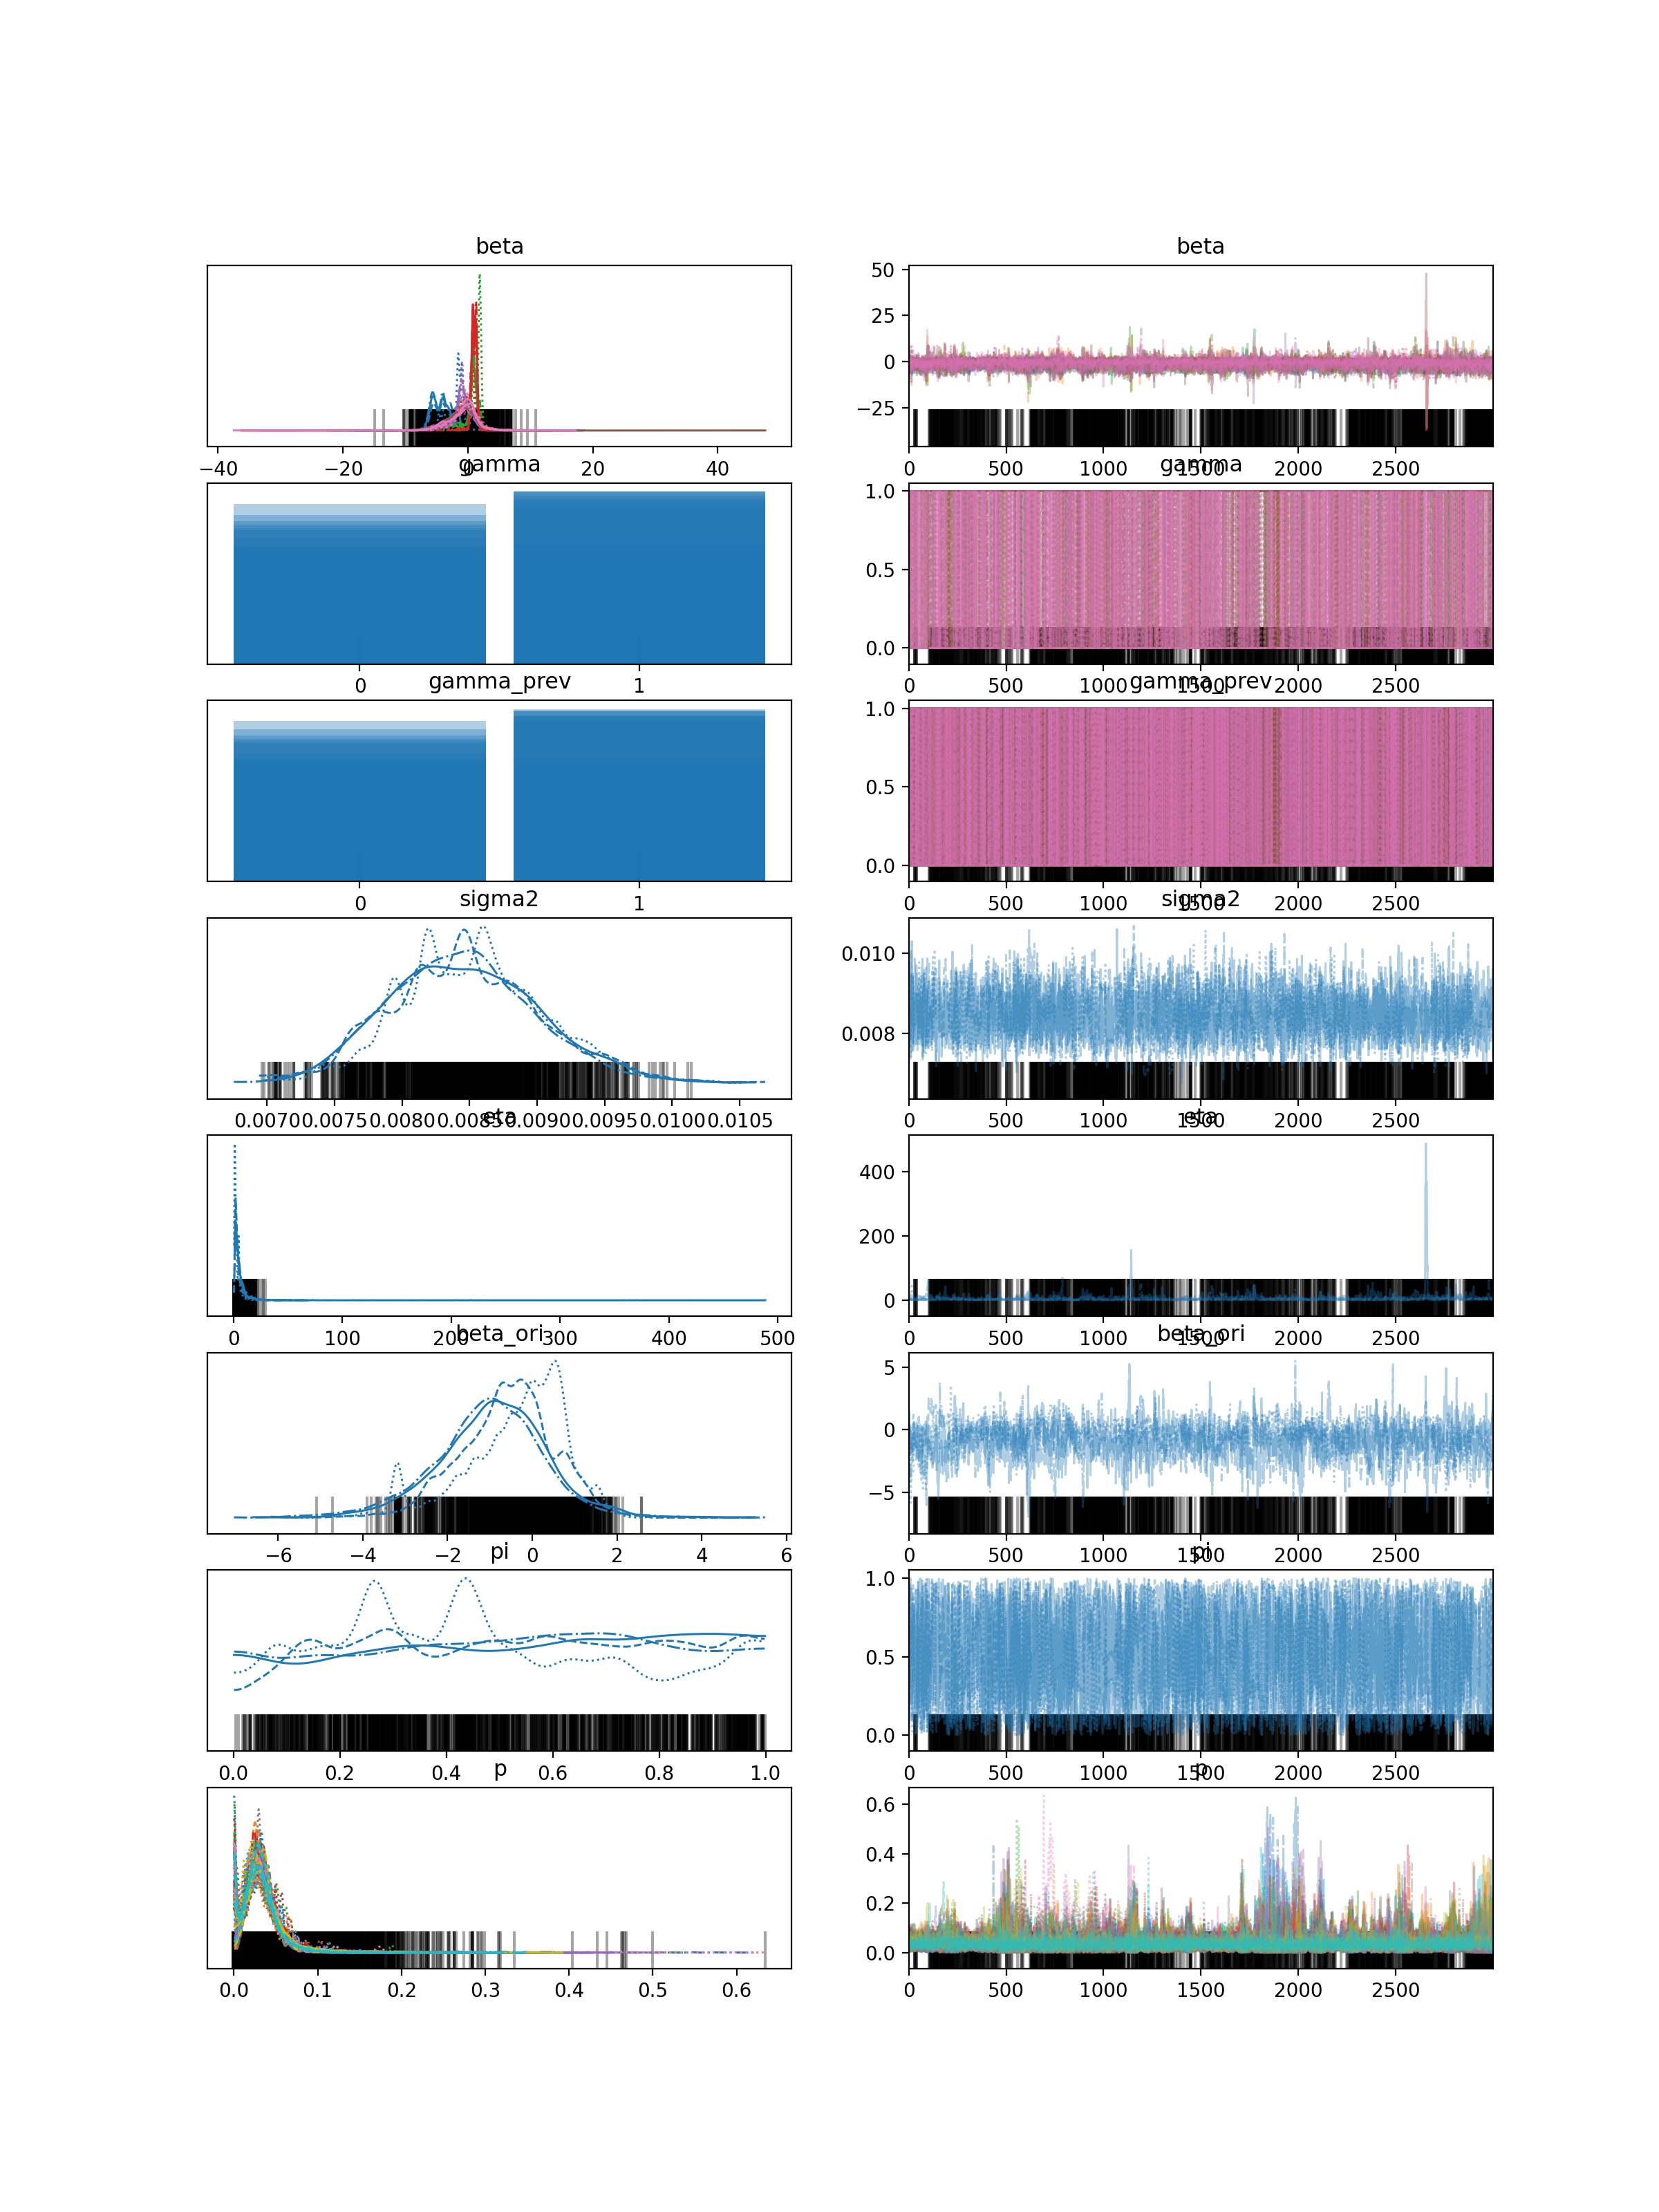

                mean      sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
beta[0]       -3.726   1.750  -6.402   -0.759      0.522    0.379      12.0   
beta[1]       -0.770   2.409  -5.657    3.350      0.068    0.048    1440.0   
beta[2]        0.489   2.113  -4.988    2.564      0.296    0.210      19.0   
beta[3]        0.754   0.975  -1.474    1.989      0.196    0.140      42.0   
beta[4]       -0.866   2.075  -5.476    2.887      0.050    0.051    1517.0   
beta[5]       -1.099   2.534  -5.917    2.914      0.069    0.049    1069.0   
beta[6]       -0.734   2.358  -5.738    3.130      0.058    0.041    1608.0   
gamma[0]       0.986   0.115   1.000    1.000      0.010    0.007     141.0   
gamma[1]       0.148   0.355   0.000    1.000      0.032    0.023     124.0   
gamma[2]       0.730   0.444   0.000    1.000      0.068    0.049      42.0   
gamma[3]       0.804   0.397   0.000    1.000      0.148    0.109       7.0   
gamma[4]       0.446   0.497   0.000    1.000      0

In [36]:

# Step 1: Generate simulated data
np.random.seed(42)
N = 3000  # Number of samples
D = 7  # Number of predictors


# Step 2: Define the PyMC model
with pm.Model() as model:
    # Priors
    # Beta for regression coefficients, grouped into classes
    alpha = pm.HalfNormal("alpha", sigma=5.0)  # Dirichlet prior concentration parameter
    #alpha=1
    p = pm.Dirichlet("p", a=pm.math.ones(30) * alpha, shape=30)  # Class probabilities
 #10 0 1 2 3 4 
    S = pm.Categorical("S", p=p, shape=D)# bp=nel shape  1 1 1  # Class assignment for predictors (0-9)
    #[1 3 5 7 9]
    eta = pm.InverseGamma("eta", alpha=2, beta=2)  # Variance for beta_m
    mu_0=pm.Normal("beta_ori",mu=0,sigma=3)
    beta_m = pm.Normal("beta_m", mu=mu_0, sigma=pm.math.sqrt(eta), shape=30)  # Regression coefficients for each class
    
    # Ensure S only indexes valid categories of beta_m
    beta = pm.Deterministic("beta", beta_m[S])  # Map beta based on S
    
    # Sparsity indicator gamma
    pi = pm.Beta("pi", alpha=1, beta=1)  # Probability of gamma=1
    gamma_prev = pm.Bernoulli("gamma_prev", p=0.5, shape=D)  # 初始值
    rho = 0.8  # 控制gamma的平稳性（越接近1越稳定）
    gamma = pm.Bernoulli("gamma", p=rho * gamma_prev + (1 - rho) * pi, shape=D)

    #gamma = pm.Bernoulli("gamma", p=pi, shape=D)

    # Noise variance (sigma^2)
    sigma2 = pm.InverseGamma("sigma2", alpha=2, beta=2)  # Prior for noise variance

    # Observed data likelihood
    mu = pm.math.dot(X_with_intercept, beta * gamma)  # Predicted mean
    #X_new_=np.exp(X_with_intercept)
    #mu = beta[0] * pm.math.prod(X_new_.to_numpy()[:, 1:] ** (beta[1:] * gamma[1:]), axis=1)


    y_obs = pm.Normal("y_obs", mu=np.exp(mu), sigma=pm.math.sqrt(sigma2), observed=np.exp(y))

    # Inference
    
    trace = pm.sample(N, tune=500, chains=4,step=pm.NUTS(target_accept=0.95), return_inferencedata=True)


# Step 3: Analyze and visualize the results
az.plot_trace(trace, var_names=["beta", "gamma", "gamma_prev","sigma2", "eta", "beta_ori","pi", "p"])
plt.show()
summary=az.summary(trace, var_names=["beta", "gamma","gamma_prev", "sigma2", "eta","beta_ori", "pi", "p"])
print(summary)

<IPython.core.display.Javascript object>


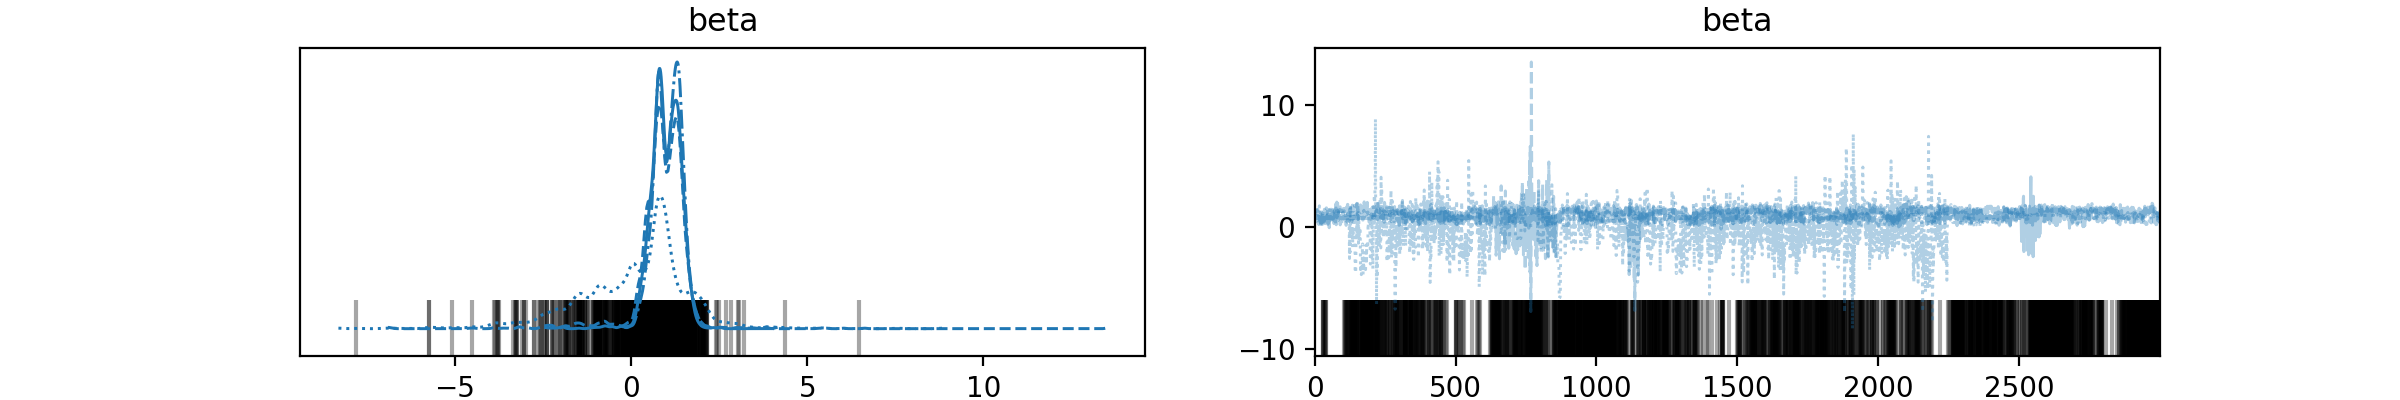

In [37]:
az.plot_trace(trace, var_names=["beta"], coords={"beta_dim_0": [3]})
plt.show()


<IPython.core.display.Javascript object>


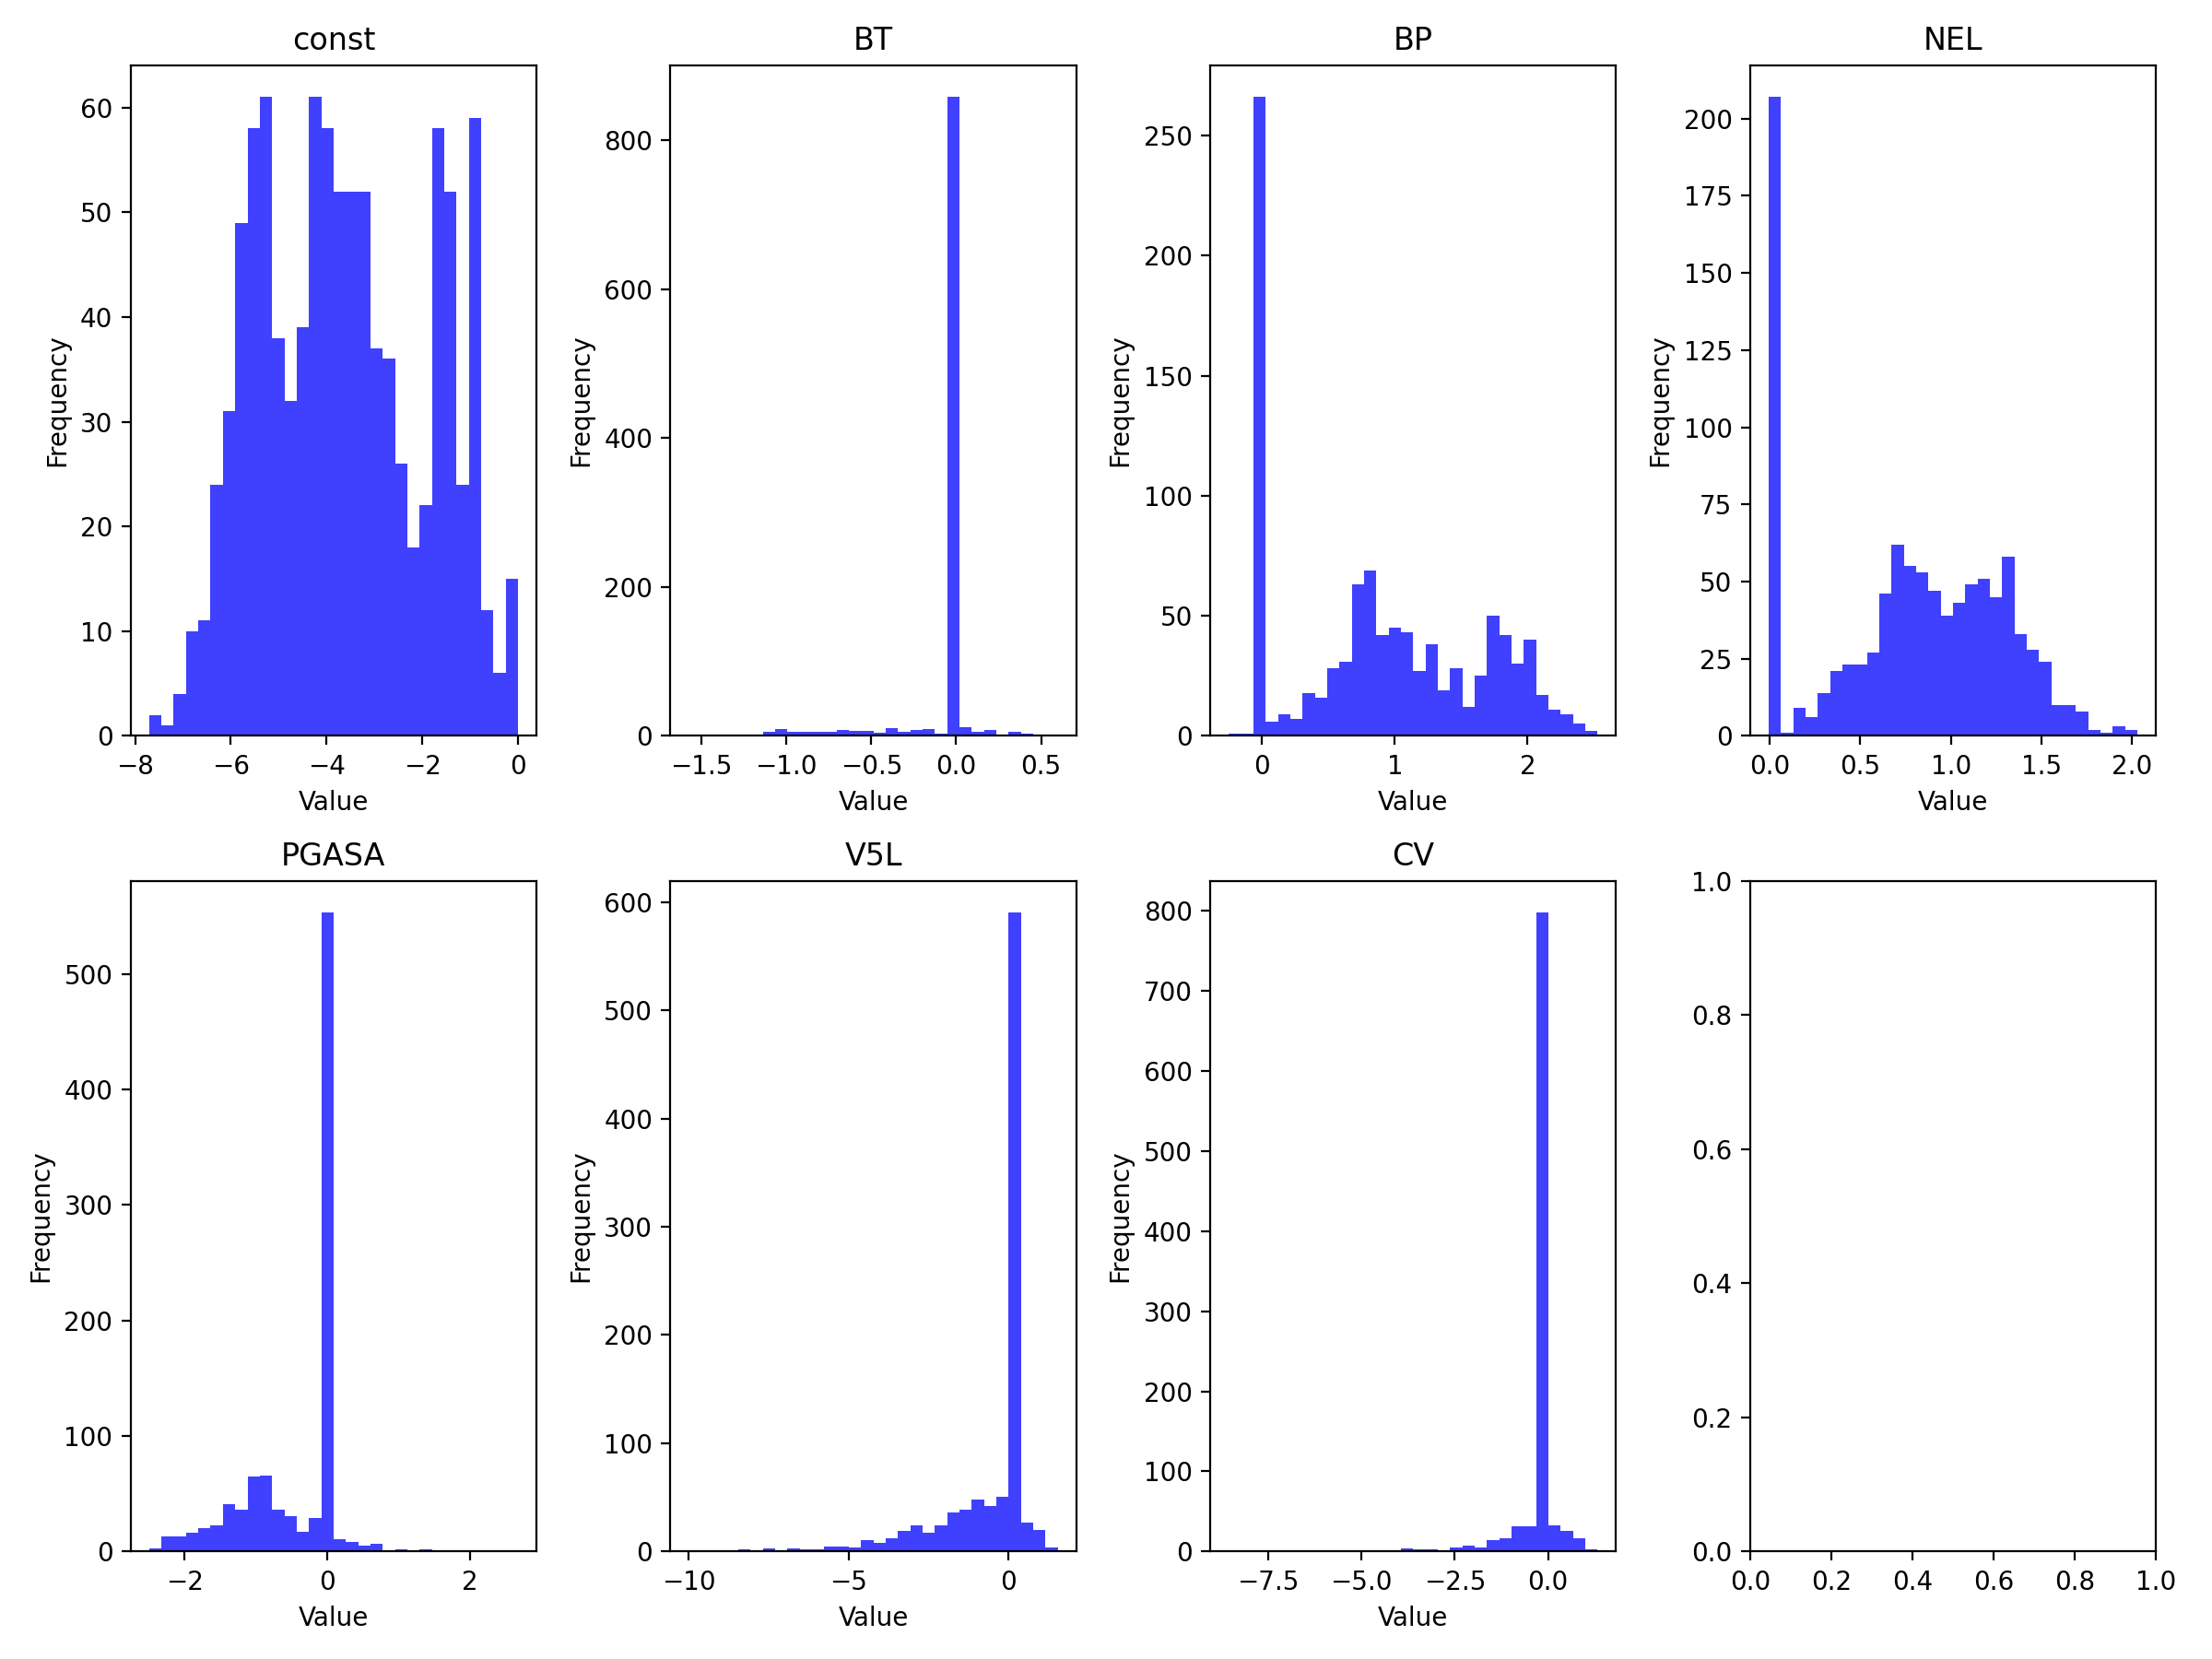

[0.985 0.147 0.741 0.798 0.464 0.446 0.244]
[-3.61948214 -0.05533504  0.8915701   0.76911072 -0.41573043 -0.67380334
 -0.14278437]
[15.037 14.697 14.308 14.673 14.626 14.645 14.195]
1000 samples' RMSE values: 0.3332


In [38]:
# 从后验中随机抽取 10 个样本
num_samples = 1000
posterior_indices = np.random.choice(
    trace.posterior["beta"].stack(samples=["chain", "draw"]).shape[1], 
    size=num_samples, 
    replace=False
)

# 定义新数据
 # 新数据 (10 个样本)

# 存储预测结果
beta_new_look = []
predictions = []
S_new = []
gamma_new=[]
for idx in posterior_indices:
    beta_sample = trace.posterior["beta"].stack(samples=["chain", "draw"]).values[:, idx]
    gamma_sample = trace.posterior["gamma"].stack(samples=["chain", "draw"]).values[:, idx]
    S_sample = trace.posterior["S"].stack(samples=["chain", "draw"]).values[:, idx]
    sigma_sample = np.sqrt(trace.posterior["sigma2"].stack(samples=["chain", "draw"]).values[idx])
    #gamma_binary = (gamma_post_mean > 0.5).astype(int)
    # 计算预测值
    mu_pred = X_with_intercept @ (beta_sample * gamma_sample)  # 预测均值
    y_pred = np.random.normal(mu_pred, sigma_sample, size=X_with_intercept.shape[0])  # 从预测分布采样
    S_new.append(gamma_sample*beta_sample)
    beta_new_look.append(S_sample)
    gamma_new.append(gamma_sample)
    predictions.append(y_pred)
S_new1 = np.array(S_new)
gamma_new = np.array(gamma_new)
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(12, 9))
axes = axes.flatten()

for i in range(7):
    ax = axes[i]
    # 只考虑 gamma 为 1 的情况
    #filtered_beta = S_new1[:, i][gamma_new[:, i] == 1]
    filtered_beta = S_new1[:, i]
    ax.hist(filtered_beta, bins=30, alpha=0.75, color='blue')
    ax.set_title(f'{X_with_intercept.columns[i]}')
    ax.set_xlabel('Value')
    ax.set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('distribution.png', format='png', dpi=300, transparent=True)
plt.show()
S_mean_new = np.array(S_new).mean(axis=0)
beta_new_look_new = np.array(beta_new_look).mean(axis=0)
gamma_mean = np.array(gamma_new).mean(axis=0) 
gamma_binary = (gamma_mean > 0.5).astype(int)
print(gamma_mean)

predictions = np.array(predictions).T  
pred_mean = predictions.mean(axis=1) 
print(S_mean_new)
print(beta_new_look_new)
'''SS_res = np.sum((pred_mean - y) ** 2)
SS_tot = np.sum((y - np.mean(y)) ** 2)
R_squared = 1 - (SS_res / SS_tot)
print(f"1000 samples' R² values=: {R_squared:.4f}")'''
# 计算 RMSE
RMSE = np.sqrt(np.mean((pred_mean - y) ** 2))
print(f"1000 samples' RMSE values: {RMSE:.4f}")


In [61]:
p11=0.0175*(1000000*(mu0 * 15) / (680/(2 * np.pi * 6.2)))**0.71*10**1.02*680*0.74

In [62]:
p11


97.37936911052206

In [ ]:
131.6  97.4  210.5  